# Energy Demand Estimation for Public Transport Bus Trips

Welcome to this notebook! 🚍⚡

This notebook provides a comprehensive, step-by-step walkthrough of the methodology used to estimate the energy demand of bus trips. The objective is to offer both a transparent documentation of the underlying calculations and a practical guide for applying them using `trip-stitcher`.

- **Input:** A bus trip.  
- **Output:** An estimated energy demand of that bus trip.  

The notebook is structured to first introduce the key concepts involved in energy demand estimation, including vehicle dynamics and route characteristics.
Finally, the notebook presents a reusable library function that encapsulates the entire workflow into a single, streamlined interface. This allows users to efficiently apply the methodology without revisiting each individual step, while still maintaining transparency into the underlying logic.

Let's go! 🚀

# Loading Data

The first step in this notebook is to load the transport data from a **Parquet file**. 

This file contains all the essential information needed for route finding, including:

- **Routes:** The different public transport lines available.  
- **Trips:** Individual scheduled trips for each route.  
- **Stops:** Geographic locations of each stop on the routes.  

Let's load the data and take a quick look at its structure.

In [1]:
from pathlib import Path

import pandas as pd

root = Path("..")

parquet_path = Path(root / "data/postauto.parquet")
df = pd.read_parquet(parquet_path)
print(f"DataFrame contains {len(df)} rows")
df.head()

DataFrame contains 2650955 rows


,agency_id,route_id,route_short_name,trip_id,service_id,monday,start_date,end_date,stop_sequence,arrival_time,departure_time,stop_id,stop_name,stop_lat,stop_lon
0,801,96-100-0-j25-1,220,1.TA.96-100-0-j25-1.8.H,TA+2e000#1,1,20241215,20251213,1,07:27:00,07:27:00,8571330,"Reichenbach i. K., Bahnhof",46.625525,7.690208
1,801,96-100-0-j25-1,220,1.TA.96-100-0-j25-1.8.H,TA+2e000#1,1,20241215,20251213,2,07:28:00,07:28:00,8571331,"Reichenbach i. K., Bären",46.625432,7.694187
2,801,96-100-0-j25-1,220,1.TA.96-100-0-j25-1.8.H,TA+2e000#1,1,20241215,20251213,3,07:30:00,07:30:00,8583254,"Scharnachtal, Halten",46.620608,7.697223
3,801,96-100-0-j25-1,220,1.TA.96-100-0-j25-1.8.H,TA+2e000#1,1,20241215,20251213,4,07:32:00,07:32:00,8507766,"Scharnachtal, Viesen",46.617979,7.697807
4,801,96-100-0-j25-1,220,1.TA.96-100-0-j25-1.8.H,TA+2e000#1,1,20241215,20251213,5,07:33:00,07:33:00,8571332,"Scharnachtal, Schulhaus",46.614709,7.698158


# Selecting a Sample Trip

In this section, we select a representative bus trip from the dataset to serve as a running example throughout the notebook.

The purpose of this step is to work with a concrete instance that allows us to clearly illustrate each stage of the energy demand estimation process.

In [2]:
from loguru import logger

logger.remove()  # prevent ocsept from logging

from trip_stitcher.models import Route, Stop, Trip

route_dict = dict(
    (route.id, route) for route in Route.list_from_dataframe(df)
)  # Route dictionary for route lookup
trip_dict = dict(
    (trip.id, trip) for trip in Trip.list_from_dataframe(df)
)  # Trip dictionary for trip lookup
stop_dict = dict(
    (stop.id, stop) for stop in Stop.list_from_dataframe(df)
)  # Stop dictionary for stop lookup

route_id = "96-241-7-j25-1"
trip = trip_dict[route_dict[route_id].trips[0]]
trip_geometry = trip.download_geometry(stop_dict)
trip

Trip(id='1.TA.96-241-7-j25-1.9.H', route='96-241-7-j25-1', stops=['8573902', '8580266', '8580494', '8580493', '8580271', '8573904', '8580906', '8580501', '8580502', '8580907', '8580503', '8582765', '8579947', '8579949', '8579950', '8573887'], arrival_times=['20:18:00', '20:19:00', '20:20:00', '20:21:00', '20:22:00', '20:24:00', '20:25:00', '20:28:00', '20:28:00', '20:29:00', '20:29:00', '20:35:00', '20:35:00', '20:36:00', '20:37:00', '20:41:00'], estimated_energy_demand=None, covered_distance=None)

# Visualizing the Sample Trip

To gain a better understanding of the selected trip, we visualize it on a map.  

Mapping the route allows us to see the geographical context, including the start and end points, the stops, and the path taken.

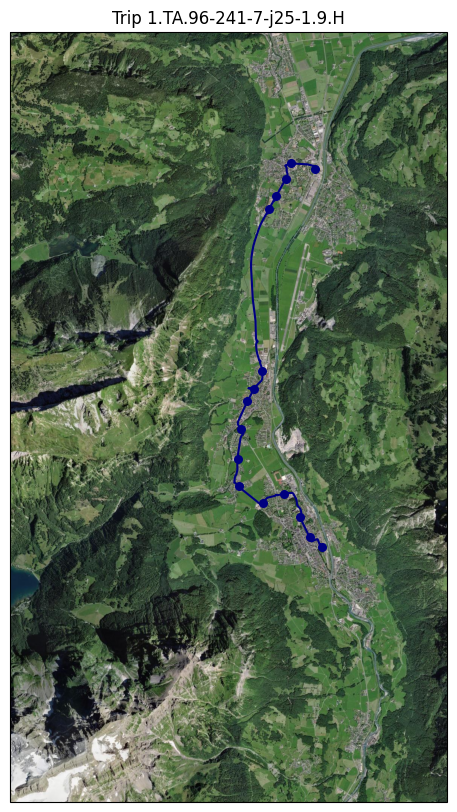

In [3]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt

# Create a tiler for OpenStreetMap
tiler = cimgt.GoogleTiles(style="satellite")  # Satellite tiles
mercator = tiler.crs  # The CRS used by the tiles (Web Mercator)

# Create the plot
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=mercator)

# Add the map tiles
ax.add_image(tiler, 14)  # zoom level 14

# Set extent
extent = [9.0, 9.1, 47.0, 47.12]
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.plot(trip_geometry.lon, trip_geometry.lat, transform=ccrs.PlateCarree(), c="navy")
ax.scatter(
    [stop_dict[stop_id].lon for stop_id in trip.stops],
    [stop_dict[stop_id].lat for stop_id in trip.stops],
    s=30,
    transform=ccrs.PlateCarree(),
    c="navy",
)

plt.title(f"Trip {trip.id}")
plt.show()

# Elevation Profile of the Trip

The elevation profile of a bus trip is a critical factor in estimating energy consumption, as changes in terrain affect the power required to move the vehicle.  

In this notebook, we sample the elevation only at the bus stops and use linear interpolation between them. This approach offers several advantages:  
- It smooths out noisy elevation data, which is common in high-resolution datasets.  
- It prevents artificially steep inclinations that could result in unrealistic or infeasible energy demand calculations.  
- It provides a simplified yet enough accurate representation of the trip’s terrain, sufficient for modeling energy consumption.  

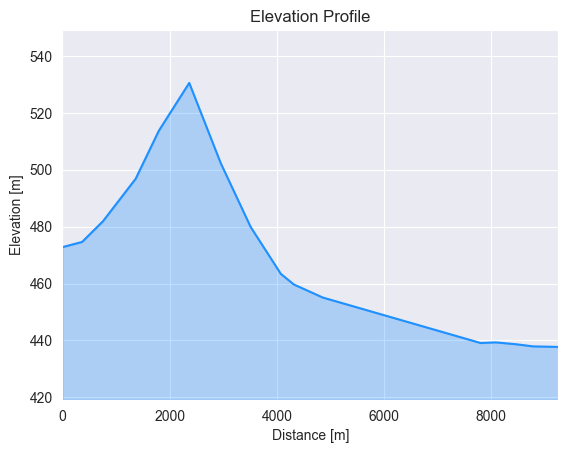

In [4]:
import seaborn as sns

from trip_stitcher.elevation import ElevationOracle

elevation_oracle = ElevationOracle()
trip_geometry = trip.download_geometry(stop_dict, elevation_oracle=elevation_oracle)


sns.set_style("darkgrid")
plt.plot(trip_geometry.cumulative_distance, trip_geometry.elevation, c="dodgerblue")
plt.fill_between(
    trip_geometry.cumulative_distance,
    trip_geometry.elevation,
    min(trip_geometry.elevation)
    - 0.2 * (max(trip_geometry.elevation) - min(trip_geometry.elevation)),
    color="dodgerblue",
    alpha=0.3,
)
plt.title("Elevation Profile")
plt.xlabel("Distance [m]")
plt.ylabel("Elevation [m]")
plt.xlim(min(trip_geometry.cumulative_distance), max(trip_geometry.cumulative_distance))
plt.ylim(
    (
        min(trip_geometry.elevation)
        - 0.2 * (max(trip_geometry.elevation) - min(trip_geometry.elevation)),
        max(trip_geometry.elevation)
        + 0.2 * (max(trip_geometry.elevation) - min(trip_geometry.elevation)),
    )
)
plt.show()

# Road Inclination Profile

The inclination (or slope) of the route directly impacts the bus’s energy consumption: uphill segments require more power, while downhill segments may allow for energy recovery or reduced consumption.  

For context, typical road inclinations for urban and suburban bus routes are usually modest, often staying below 6–8%. Extreme slopes are uncommon and may lead to operational challenges or infeasible energy requirements.

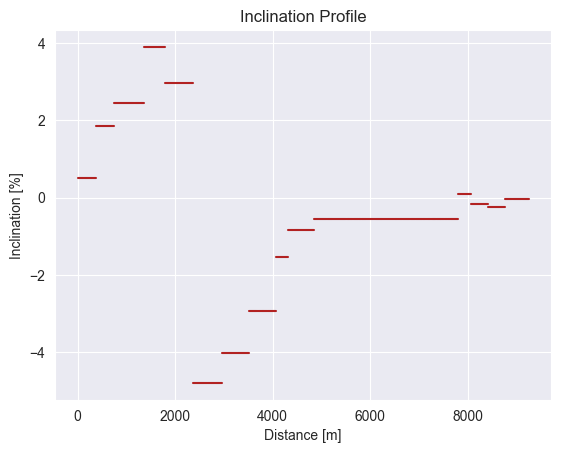

In [5]:
inclination = []
for d, e1, e2 in zip(
    trip_geometry.distance, trip_geometry.elevation[:-1], trip_geometry.elevation[1:]
):
    if d == 0:
        inclination.append(
            0
        )  # this will not be seen on the plot since the length of the line is zero
    else:
        inclination.append(100 * (e2 - e1) / d)

for inc, d1, d2 in zip(
    inclination, trip_geometry.cumulative_distance[:-1], trip_geometry.cumulative_distance[1:]
):
    plt.plot([d1, d2], [inc, inc], c="firebrick")

plt.title("Inclination Profile")
plt.xlabel("Distance [m]")
plt.ylabel("Inclination [%]")

plt.show()

# Estimating Speed Limits for Each Segment

Energy consumption also depends heavily on the speed profile of the bus along the route. Since we do not have direct speed limit data for each road segment, we infer approximate speed limits using the driven speeds provided by OSRM for each segment.  

This approach allows us to make realistic guesses of the maximum allowable speeds on each segment, which are then used to constrain the modeled speed profile in the energy calculations.  

To visualize these estimates, we plot the maximum speed limit along the trip, providing a clear reference for how fast the bus could potentially travel on each segment.

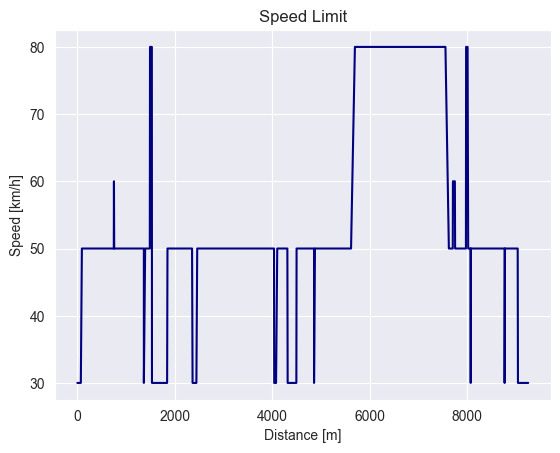

In [6]:
plt.plot(trip_geometry.cumulative_distance[1:], trip_geometry.speed_limit, c="navy")
plt.title("Speed Limit")
plt.ylabel("Speed [km/h]")
plt.xlabel("Distance [m]")
plt.show()

# Speed and Traction Force Profiles

A fundamental part of calculating the energy consumption of a bus trip is knowing both the **speed profile** and the **traction force profile** along the route.  

These profiles describe how the bus accelerates, decelerates, and overcomes resistive forces at each point of the trip. In this notebook, we compute them using the `ocsept` package, which models vehicle dynamics to produce realistic profiles.  

Below, we plot the resulting speed and traction force profiles, providing a visual representation of how the bus moves along the route and how the forces required to maintain that motion vary over time.

In [7]:
from contextlib import contextmanager

from IPython.utils.io import capture_output
from ocsept.data.generation.speed.time_optimal import TimeOptimalStrategy
from ocsept.models.transport.comfort import RidingComfort
from ocsept.models.transport.mission import DrivingMission as OcseptDrivingMission
from ocsept.simulation.qss import LongitudinalVehicleDynamics

from trip_stitcher.vehicles.mega import bus


@contextmanager
def suppress_output():
    with capture_output():
        yield


itinerary = trip_geometry.create_itinerary()

comfort = RidingComfort()
speed_profile = TimeOptimalStrategy().process(itinerary, bus, comfort)
mission = OcseptDrivingMission(
    name="Fastest possible travel speed",
    time=speed_profile.time,
    speed=speed_profile.speed,
    inclination=itinerary.get_inclination(speed_profile.distance),
    payload="0 kg",
)
with suppress_output():
    vehicle_dynamics = LongitudinalVehicleDynamics.of(bus, mission)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



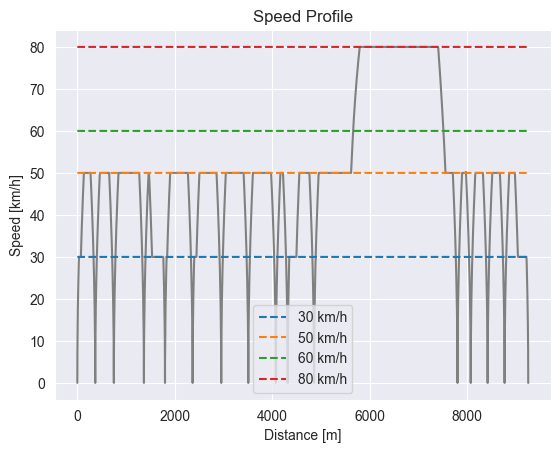

In [8]:
plt.plot(speed_profile.distance.magnitude, speed_profile.speed.magnitude, c="gray")
for speed_limit in [30, 50, 60, 80]:
    plt.plot(
        speed_profile.distance.magnitude,
        [speed_limit] * len(speed_profile.distance),
        label=f"{speed_limit} km/h",
        linestyle="dashed",
    )
plt.xlabel("Distance [m]")
plt.ylabel("Speed [km/h]")
plt.legend()
plt.title("Speed Profile")
plt.show()

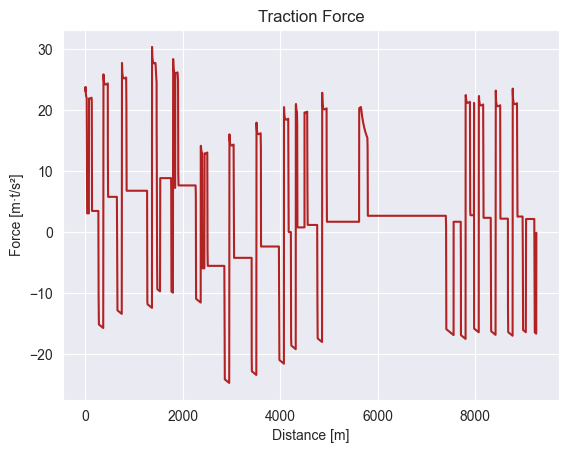

In [9]:
plt.plot(speed_profile.distance.magnitude, vehicle_dynamics.traction_force.magnitude, c="firebrick")
plt.xlabel("Distance [m]")
plt.ylabel(f"Force [{vehicle_dynamics.traction_force.units}]")
plt.title("Traction Force")
plt.show()

# Calculating Propulsion Power and Energy

The propulsion power at each point along the trip is calculated by multiplying the **speed** by the corresponding **traction force**.  

Once we have the power profile, the total energy required for propulsion is obtained by summing the product of power and the duration of each timestep. This step integrates the instantaneous power over the entire trip, providing the total energy consumed to move the bus along the route.

This calculation forms the core of the energy demand estimation, linking the vehicle dynamics directly to energy consumption.

In [10]:
import numpy as np

average_velocity = speed_profile.speed[:-1] + speed_profile.speed[1:] / 2
p_mech = average_velocity * vehicle_dynamics.traction_force[:-1]

efficiency = 0.9
propulsion_power = np.where(p_mech >= 0, p_mech / efficiency, p_mech * efficiency)
propulsion_energy = np.sum(np.diff(speed_profile.time) * propulsion_power).to("J")
propulsion_energy

<Quantity(40080601.8, 'joule')>

# Using the `EnergyDemandEstimator` Class

For convenience and reproducibility, the project provides a class called `EnergyDemandEstimator` that encapsulates all the computations demonstrated above.  

Key features of this class include:  
- **Full workflow integration:** It handles speed and traction force calculations, propulsion power, and energy summation automatically.  
- **Caching of results:** Since the computation can be time-consuming, results for previously processed trips are cached. Recalculating the same trip is therefore fast, as it only requires a lookup.  
- **Auxiliary power inclusion:** The class allows the addition of auxiliary power consumption (e.g., HVAC, lighting, electronics) to obtain the **total energy used** for a complete picture of the bus’s energy demand.

In [11]:
from time import perf_counter

from trip_stitcher.energy_demand_estimator import EnergyDemandEstimator

ed_estimator = EnergyDemandEstimator(df)

start_time = perf_counter()
energy = ed_estimator.calculate_energy_demand(trip, bus_type="mega")
print(f"Energy = {energy} J\t({perf_counter() - start_time:.3f} seconds)")

speed_profile_solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
               nlp_f  |   4.00ms (160.00us)   4.15ms (166.16us)        25
               nlp_g  | 446.00ms ( 17.84ms) 446.93ms ( 17.88ms)        25
          nlp_grad_f  |   9.00ms (173.08us)  11.24ms (216.08us)        52
          nlp_hess_l  |   1.06 s ( 44.25ms)   1.07 s ( 44.60ms)        24
           nlp_jac_g  |   1.08 s ( 41.46ms)   1.07 s ( 41.31ms)        26
               total  |   5.77 s (  5.77 s)   5.77 s (  5.77 s)         1
Energy = 40081582.88492516 J	(35.337 seconds)


In [13]:
for i in range(5):
    start_time = perf_counter()
    energy = ed_estimator.calculate_energy_demand(trip, bus_type="mega")
    print(f"  {i + 1}. Energy = {energy} J\t({perf_counter() - start_time:.6f} seconds)")

total_energy = ed_estimator.calculate_energy_demand(
    trip, bus_type="mega", aux_power=2.0e3
)  # aux power of 2 kW
print(f"Energy including auxilary power: {total_energy} J")
print(f"Driven distance: {trip.covered_distance} m")

  1. Energy = 40081582.88492516 J	(0.000132 seconds)
  2. Energy = 40081582.88492516 J	(0.000007 seconds)
  3. Energy = 40081582.88492516 J	(0.000003 seconds)
  4. Energy = 40081582.88492516 J	(0.000002 seconds)
  5. Energy = 40081582.88492516 J	(0.000003 seconds)
Energy including auxilary power: 42841582.88492516 J
Driven distance: 9252.4035605354 m
